In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

## Задание 1
### Загрузка DataFrame

In [40]:
column_names = ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'class']
iris = pd.read_csv("data/iris/iris.data", names=column_names)
print("Начало датасета ирисов")
iris.head()

Начало датасета ирисов


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Нахождение корреляций

In [41]:
print("Общая корреляция ирисов")
iris.corr(numeric_only=True)

Общая корреляция ирисов


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,1.000000,-0.109369,0.871754,0.817954
sepal_width_cm,-0.109369,1.000000,-0.420516,-0.356544
petal_length_cm,0.871754,-0.420516,1.000000,0.962757
petal_width_cm,0.817954,-0.356544,0.962757,1.000000


In [42]:
print("Сгруппированная корреляция по классам ирисов")
iris.groupby("class").corr()

Сгруппированная корреляция по классам ирисов


sepal_length_cm  sepal_width_cm  \
class                                                              
Iris-setosa     sepal_length_cm         1.000000        0.746780   
                sepal_width_cm          0.746780        1.000000   
                petal_length_cm         0.263874        0.176695   
                petal_width_cm          0.279092        0.279973   
Iris-versicolor sepal_length_cm         1.000000        0.525911   
                sepal_width_cm          0.525911        1.000000   
                petal_length_cm         0.754049        0.560522   
                petal_width_cm          0.546461        0.663999   
Iris-virginica  sepal_length_cm         1.000000        0.457228   
                sepal_width_cm          0.457228        1.000000   
                petal_length_cm         0.864225        0.401045   
                petal_width_cm          0.281108        0.537728   

                                 petal_length_cm  petal_width_cm  
class                                                             
Iris-setosa     sepal_length_cm         0.263874        0.279092  
                sepal_width_cm          0.176695        0.279973  
                petal_length_cm         1.000000        0.306308  
                petal_width_cm          0.306308        1.000000  
Iris-versicolor sepal_length_cm         0.754049        0.546461  
                sepal_width_cm          0.560522        0.663999  
                petal_length_cm         1.000000        0.786668  
                petal_width_cm          0.786668        1.000000  
Iris-virginica  sepal_length_cm         0.864225        0.281108  
                sepal_width_cm          0.401045        0.537728  
                petal_length_cm         1.000000        0.322108  
                petal_width_cm          0.322108        1.000000

### Графика

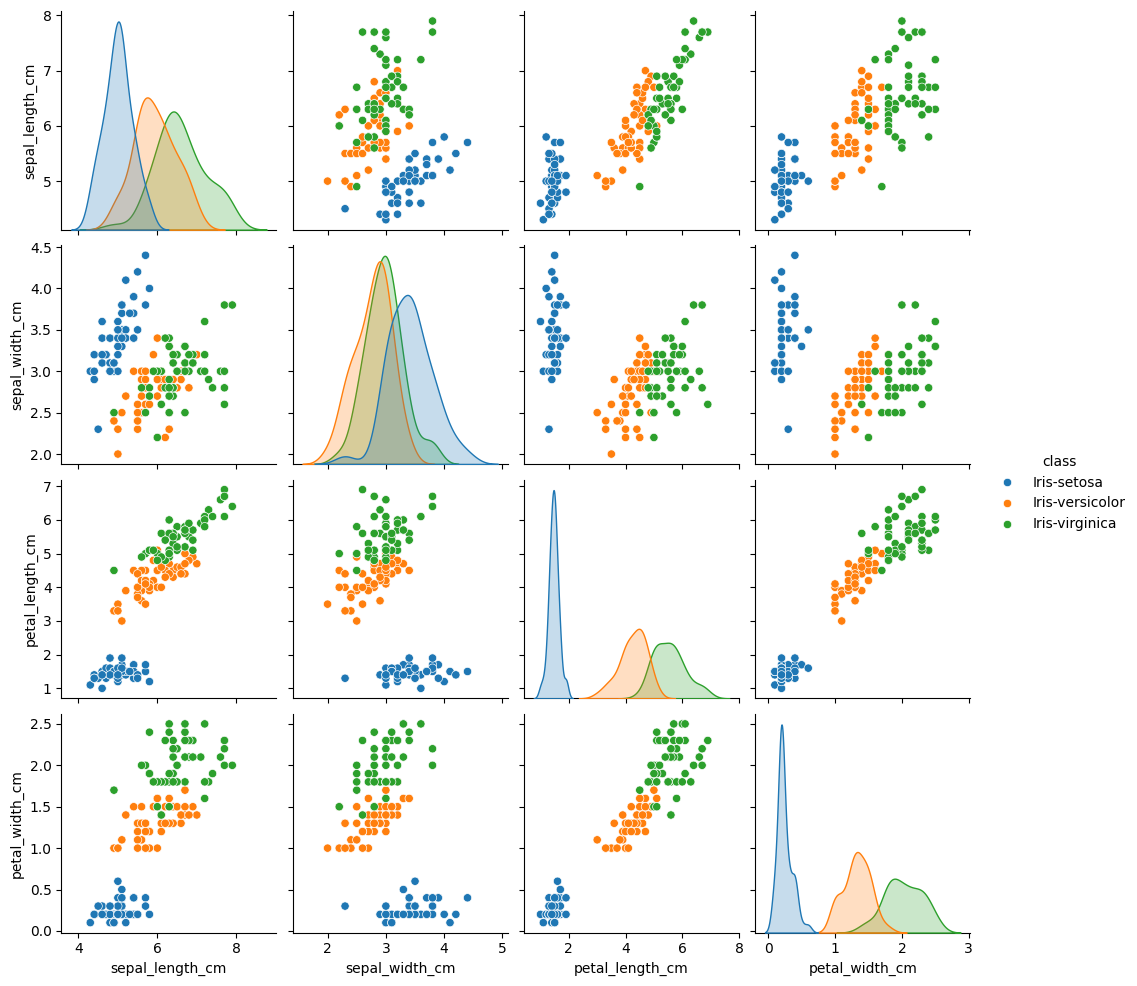

In [ ]:
sns.pairplot(iris, hue='class')

## Задание 2

### Подготовка данных

In [ ]:
X = iris[['petal_length_cm', 'petal_width_cm']].values
Y, unique_classes = pd.factorize(iris['class'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.3, random_state=0)

### Функция для визуалиации

In [ ]:
def plot_decision_regions(X, Y, classifier, test_idx=None, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(Y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(Y)):
        plt.scatter(x=X[Y == cl, 0], y=X[Y == cl, 1],
                    alpha=0.8, color=cmap(idx),
                    marker=markers[idx], label=cl)

### Решение методом линейного дискриминанта

In [ ]:
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*lda.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*lda.score(X_test, Y_test)))

Точность на тренировочных данных 95.24 %
Точность на тестовых данных 95.56 %


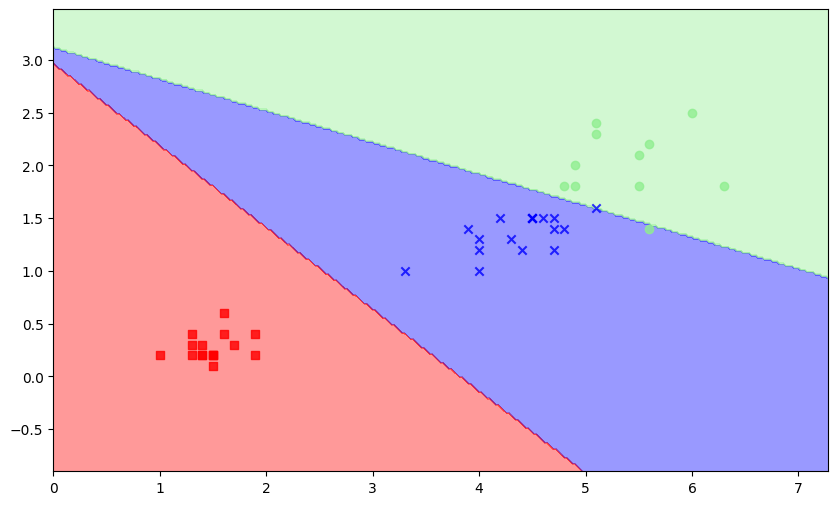

In [ ]:
plot_decision_regions(X_test, Y_test, lda)

### Решение методом квадратичного дискриминанта

In [ ]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*qda.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*qda.score(X_test, Y_test)))

Точность на тренировочных данных 96.19 %
Точность на тестовых данных 100.00 %


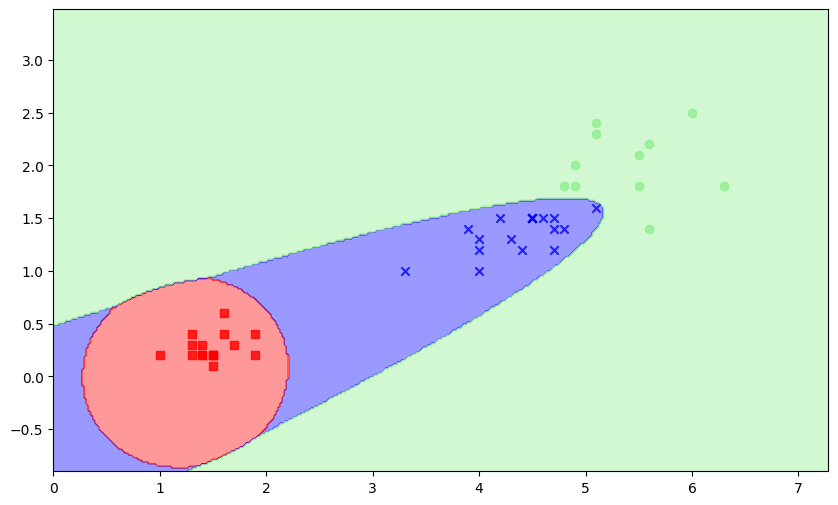

In [ ]:
plot_decision_regions(X_test, Y_test, qda)

### Решение методом логистической регрессии

In [ ]:
reg = LogisticRegression()
reg.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*reg.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*reg.score(X_test, Y_test)))

Точность на тренировочных данных 97.14 %
Точность на тестовых данных 97.78 %


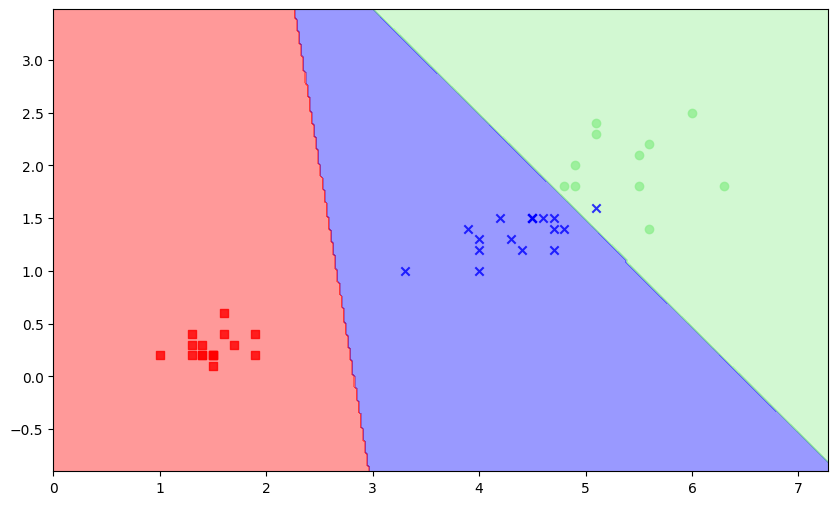

In [ ]:
plot_decision_regions(X_test, Y_test, reg)

### Решение методом SVM используя линейное ядро

In [ ]:
svml = SVC(kernel='linear')
svml.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*svml.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*svml.score(X_test, Y_test)))

Точность на тренировочных данных 97.14 %
Точность на тестовых данных 97.78 %


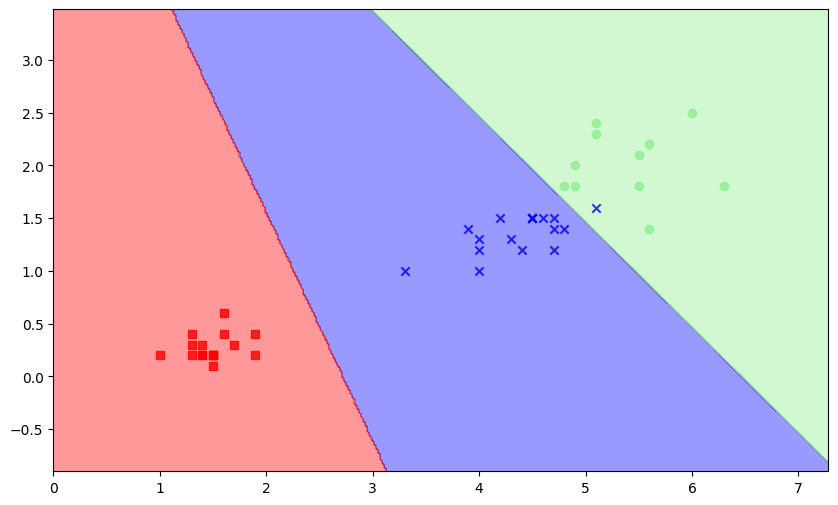

In [ ]:
plot_decision_regions(X_test, Y_test, svml)

### Решение методом SVM используя квадратичное ядро

In [ ]:
svmq = SVC(kernel='poly', degree=2)
svmq.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*svmq.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*svmq.score(X_test, Y_test)))

Точность на тренировочных данных 97.14 %
Точность на тестовых данных 97.78 %


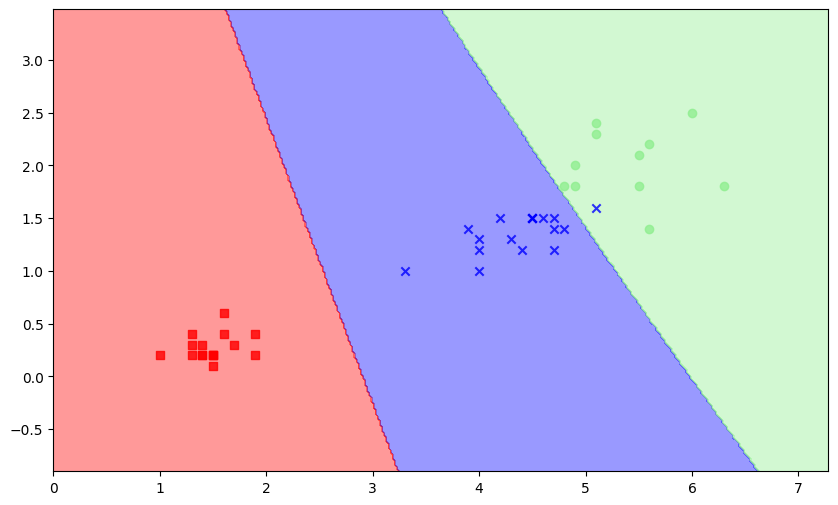

In [ ]:
plot_decision_regions(X_test, Y_test, svmq)

## Задание 3

## Задание 4

### Реализация метода использующего оценку ковариационных матриц и средних

In [ ]:
class QuadraticDiscriminant:
    def __init__(self):
        self.means = {}
        self.covariances = {}
        self.priors = {}

    def fit(self, X, Y):        
        for c in np.unique(Y):
            X_c = X[Y == c] # Выборка объектов
            self.means[c] = np.mean(X_c, axis=0) # Вычисление среднего
            self.covariances[c] = np.cov(X_c.T) # Вычисление ковариационной матрицы
            self.priors[c] = X_c.shape[0] / X.shape[0] # Вычисление априорной вероятности

        return self

    def predict(self, X):
        classes = list(self.means.keys())
        predictions = []
        for x in X:
            scores = []
            for c in classes:
                diff = x - self.means[c] # Разность между вектором x и средним класса c
                det_cov = np.linalg.det(self.covariances[c]) # Вычисление детерминанта ковариационной матрицы
                inv_cov = np.linalg.inv(self.covariances[c]) # Вычисление обратной матрицы
                quad_form = np.dot(np.dot(diff.T, inv_cov), diff) # Вычисление квадратичной формы
                
                # Вычисление значения квадратичной разделяющей функции
                score = -0.5 * quad_form - 0.5 * np.log(det_cov) + np.log(self.priors[c])
                scores.append(score)
            
            # Выбор класса с максимальным значением дискриминантной функции
            predictions.append(classes[np.argmax(scores)])
        
        return np.array(predictions)

    def score(self, X, Y):
        Y_pred = self.predict(X)
        accuracy = np.mean(Y_pred == Y)
        return accuracy

### Решение методом оценки ковариационных матриц и средних

In [ ]:
qd = QuadraticDiscriminant()
qd.fit(X_train, Y_train)

print('Точность на тренировочных данных {:.2f} %'.format(100*qd.score(X_train, Y_train)))
print('Точность на тестовых данных {:.2f} %'.format(100*qd.score(X_test, Y_test)))

Точность на тренировочных данных 96.19 %
Точность на тестовых данных 100.00 %


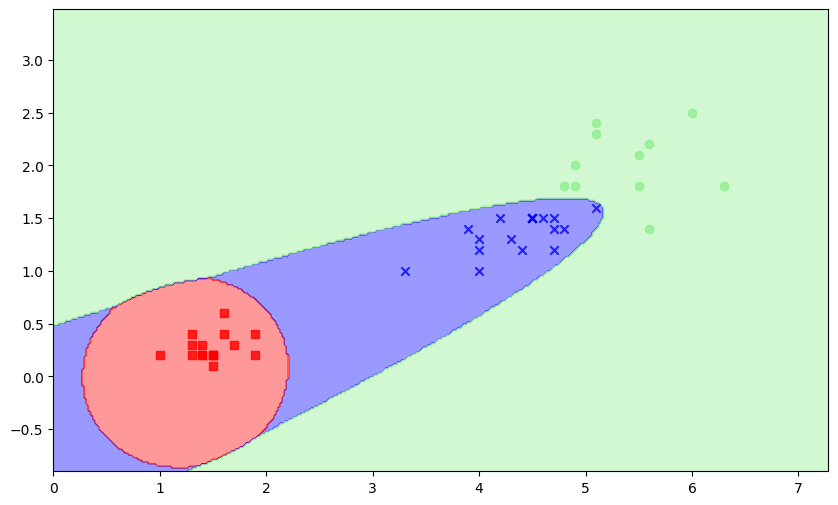

In [ ]:
plot_decision_regions(X_test, Y_test, qd)